In [1]:
import mne
import numpy as np
import pyedflib

#using one patient, load data and corresponding sleep state labels(not relevant for feature extraction, but useful for sanity check)

rec_path = "sleep-edf-database-1.0.0/st7022j0.rec"
hyp_path = "sleep-edf-database-1.0.0/st7022j0.hyp"

import shutil

src = "sleep-edf-database-1.0.0/st7022j0.rec"
dst = "sleep-edf-database-1.0.0/st7022j0.edf"

shutil.copyfile(src, dst)

print("=== LOAD REC ===")
raw = mne.io.read_raw_edf(dst, preload=False, verbose=False)
print("Channel names:", raw.ch_names)
print("Sampling rate:", raw.info["sfreq"])
print("Duration (sec):", raw.n_times / raw.info["sfreq"])

# Try to grab Fpz-Cz if it exists
candidate = None
for ch in raw.ch_names:
    if "Fpz" in ch or "FPZ" in ch or "fpz" in ch:
        candidate = ch
        break

print("Chosen EEG channel:", candidate)

if candidate is not None:
    raw_pick = raw.copy().pick([candidate]).load_data()
    eeg = raw_pick.get_data()[0]
    print("EEG shape:", eeg.shape)
    print("First 10 EEG samples:", eeg[:10])
else:
    print("No Fpz-like channel found")

print("\n=== LOAD HYP ===")
hyp = pyedflib.EdfReader(hyp_path)
print("Hyp signals_in_file:", hyp.signals_in_file)
print("Hyp labels:", hyp.getSignalLabels())

for i in range(hyp.signals_in_file):
    sig = hyp.readSignal(i)
    print(f"Hyp signal {i} shape:", sig.shape)
    print(f"Hyp signal {i} unique values (first 20):", np.unique(sig)[:20])
    print(f"Hyp signal {i} first 50 values:", sig[:50])

=== LOAD REC ===


/var/folders/nl/k9vvzpz57vj2dcsjwk1pfq780000gp/T/ipykernel_71092/4118367326.py:18: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(dst, preload=False, verbose=False)


Channel names: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental', 'ID+Sync+Error']
Sampling rate: 100.0
Duration (sec): 39790.0
Chosen EEG channel: EEG Fpz-Cz
Reading 0 ... 3978999  =      0.000 ... 39789.990 secs...
EEG shape: (3979000,)
First 10 EEG samples: [ 4.04687786e-05  5.03570775e-05  4.59622780e-05  4.85259110e-05
  4.92583776e-05  5.03570775e-05  4.15674785e-05  4.92583776e-05
  4.19337118e-05 -1.88610145e-05]

=== LOAD HYP ===
Hyp signals_in_file: 1
Hyp labels: ['Hypnogram']
Hyp signal 0 shape: (1327,)
Hyp signal 0 unique values (first 20): [0. 1. 2. 3. 4. 5. 9.]
Hyp signal 0 first 50 values: [0. 9. 9. 9. 9. 9. 9. 9. 9. 9. 9. 9. 9. 9. 9. 9. 9. 9. 9. 9. 9. 9. 9. 9.
 9. 9. 9. 9. 9. 9. 9. 9. 9. 9. 9. 9. 9. 9. 9. 9. 9. 9. 9. 9. 9. 9. 9. 9.
 9. 9.]


In [2]:
#epoch into 30 second windows
sfreq = int(raw.info["sfreq"])
samples_per_epoch = 30 * sfreq   # 3000
n_complete_epochs = len(eeg) // samples_per_epoch

eeg_trim = eeg[:n_complete_epochs * samples_per_epoch]
epochs = eeg_trim.reshape(n_complete_epochs, samples_per_epoch)

print("Epochs shape:", epochs.shape)   # expect (num_epochs, 3000)

Epochs shape: (1326, 3000)


In [3]:
#take each 30 second epoch
#divide into thirty 1-second intervals
#for each interval, subtact intervals mean and find zero crossings
#use zero crossing segments to compute x = [x1, x2, x3]:
# x1: mean segment length
# x2: std dev of segment lengths
# x3: expression - sum from i =1 to I of (e(i+1)-e(i))*integral from e(i) to e(i+1) of abs(s(t)) dt, where e(i) is the i-th zero crossing, I is the number of ZCP segments, and s(t) denotes EEG signal

In [3]:
#helper functions:
def zero_mean_interval(sig_1s):
    """Subtract mean from a 1-second interval."""
    return sig_1s - np.mean(sig_1s)


def get_zero_crossing_indices(sig):
    """
    Return indices where sign changes occur.
    sig should already be zero-meaned.
    """
    signs = np.sign(sig)

    # handle exact zeros so sign-change logic doesn't break
    for i in range(len(signs)):
        if signs[i] == 0:
            signs[i] = 1 if i == 0 else signs[i - 1]

    zc = np.where(np.diff(signs) != 0)[0]
    return zc



In [5]:
#compute x for one epoch
def compute_x_features(epoch, sfreq):
    """
    Compute paper's first feature vector x = [x1, x2, x3]
    for one 30-second epoch.

    epoch: shape (3000,) if sfreq=100
    """
    samples_per_sec = sfreq
    assert len(epoch) == 30 * samples_per_sec, "Expected one 30-second epoch"

    all_segment_lengths = []
    x3_total = 0.0

    # divide 30s epoch into thirty 1-second intervals
    for sec in range(30):
        start = sec * samples_per_sec
        end = (sec + 1) * samples_per_sec
        seg_1s = epoch[start:end]

        # subtract interval mean
        seg_1s = zero_mean_interval(seg_1s)

        # zero crossings
        zc = get_zero_crossing_indices(seg_1s)

        # need at least 2 ZCs to define one segment
        if len(zc) < 2:
            continue

        # lengths between consecutive zero crossings
        for i in range(len(zc) - 1):
            e_i = zc[i]
            e_ip1 = zc[i + 1]

            seg_len_samples = e_ip1 - e_i
            seg_len_sec = seg_len_samples / sfreq
            all_segment_lengths.append(seg_len_sec)

            # area under |s(t)| on this segment
            area = np.sum(np.abs(seg_1s[e_i:e_ip1])) / sfreq

            # x3 contribution
            x3_total += seg_len_sec * area

    if len(all_segment_lengths) == 0:
        return np.array([np.nan, np.nan, np.nan])

    x1 = np.mean(all_segment_lengths)
    x2 = np.std(all_segment_lengths)
    x3 = x3_total

    return np.array([x1, x2, x3], dtype=float)

In [6]:
#testing on one epoch
x0 = compute_x_features(epochs[0], sfreq)
print("x for epoch 0:", x0)

x for epoch 0: [4.70997680e-02 6.17508411e-02 5.81594085e-05]


In [7]:
X = np.array([compute_x_features(ep, sfreq) for ep in epochs])

print("X shape:", X.shape)   # (n_epochs, 3)
print("First 5 rows:\n", X[:5])
print("Any NaNs?", np.isnan(X).any())

X shape: (1326, 3)
First 5 rows:
 [[4.70997680e-02 6.17508411e-02 5.81594085e-05]
 [3.68361582e-02 4.02413796e-02 1.61334159e-05]
 [3.67337461e-02 4.47733924e-02 1.99599246e-05]
 [3.91578947e-02 4.40868661e-02 1.88274389e-05]
 [3.82268371e-02 4.24853252e-02 1.58955862e-05]]
Any NaNs? True


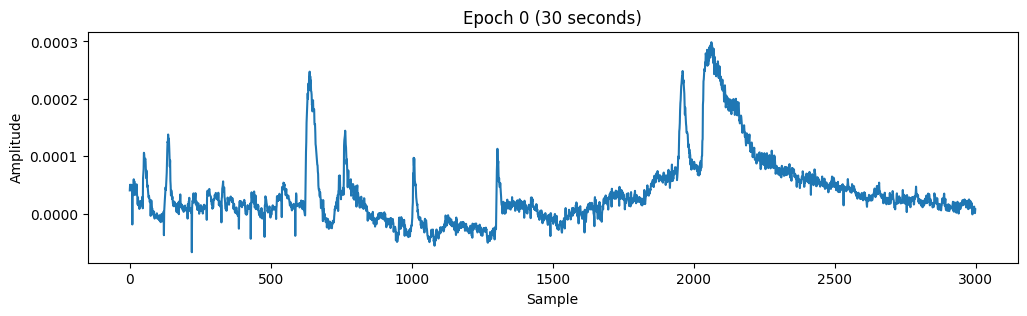

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 3))
plt.plot(epochs[0])
plt.title("Epoch 0 (30 seconds)")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

In [9]:
for i in range(5):
    print(i, compute_x_features(epochs[i], sfreq))

0 [4.70997680e-02 6.17508411e-02 5.81594085e-05]
1 [3.68361582e-02 4.02413796e-02 1.61334159e-05]
2 [3.67337461e-02 4.47733924e-02 1.99599246e-05]
3 [3.91578947e-02 4.40868661e-02 1.88274389e-05]
4 [3.82268371e-02 4.24853252e-02 1.58955862e-05]


In [6]:
import numpy as np
import matplotlib.pyplot as plt

def zero_mean_interval(x):
    return x - np.mean(x)

def get_zero_crossing_indices(sig):
    """
    Return indices where the signal changes sign.
    This uses consecutive samples with opposite signs.
    """
    sig = np.asarray(sig)
    return np.where(sig[:-1] * sig[1:] < 0)[0] + 1

def get_epoch_zero_crossings(epoch, sfreq):
    """
    Get all zero crossing indices for a 30-second epoch,
    using the same 1-second interval preprocessing as compute_x_features().
    
    Returns
    -------
    zc_global : np.ndarray
        Zero crossing indices in epoch-wide coordinates
    epoch_zero_mean : np.ndarray
        Epoch reconstructed from 1-second zero-mean intervals
    """
    samples_per_sec = sfreq
    assert len(epoch) == 30 * samples_per_sec, "Expected one 30-second epoch"

    zc_global = []
    epoch_zero_mean = np.zeros_like(epoch, dtype=float)

    for sec in range(30):
        start = sec * samples_per_sec
        end = (sec + 1) * samples_per_sec

        seg_1s = epoch[start:end]
        seg_1s_zm = zero_mean_interval(seg_1s)
        epoch_zero_mean[start:end] = seg_1s_zm

        zc_local = get_zero_crossing_indices(seg_1s_zm)
        zc_global.extend(start + zc_local)

    return np.array(zc_global), epoch_zero_mean

# def plot_epoch_with_zero_crossings(epoch, sfreq, show_segments=True):
#     """
#     Plot the epoch and mark all zero crossing points.
#     If show_segments=True, draw vertical dashed lines at each zero crossing.
#     """
#     zc_idx, epoch_zero_mean = get_epoch_zero_crossings(epoch, sfreq)

#     plt.figure(figsize=(14, 4))
#     plt.plot(epoch_zero_mean, label="Epoch (1-second zero-mean segments)")

#     if len(zc_idx) > 0:
#         plt.scatter(
#             zc_idx,
#             epoch_zero_mean[zc_idx],
#             s=18,
#             label="Zero crossings"
#         )

#         if show_segments:
#             for idx in zc_idx:
#                 plt.axvline(idx, linestyle="--", alpha=0.25)

#     plt.title("Epoch with Zero Crossing Points")
#     plt.xlabel("Sample")
#     plt.ylabel("Amplitude")
#     plt.legend()
#     plt.show()

#     return zc_idx, epoch_zero_mean
def plot_clean_zero_crossings(epoch, sfreq):
    zc_idx, epoch_zero_mean = get_epoch_zero_crossings(epoch, sfreq)

    plt.figure(figsize=(14, 3))
    plt.plot(epoch_zero_mean, linewidth=1)

    # draw vertical lines ONLY (no scatter, no clutter)
    for idx in zc_idx:
        plt.axvline(idx, alpha=0.2)

    plt.title("Zero Crossing Locations (Epoch 0)")
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")
    plt.show()

    return zc_idx

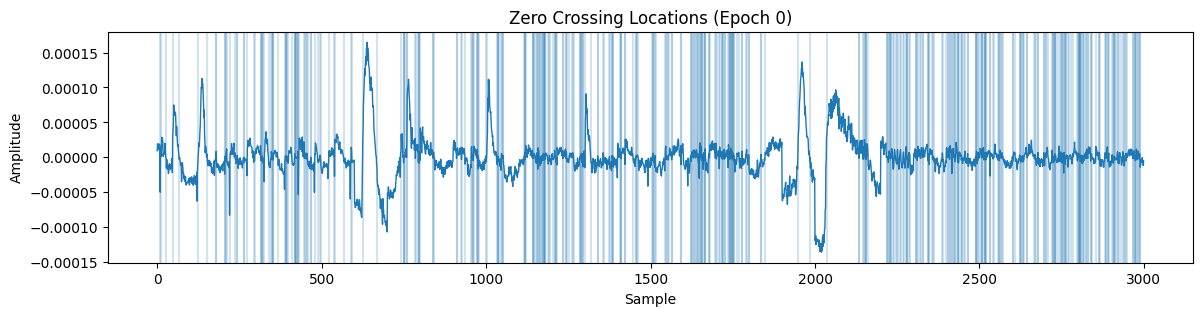

ValueError: too many values to unpack (expected 2)

In [11]:
zc_idx, epoch_zm = plot_clean_zero_crossings(epochs[0], sfreq)
print("Number of zero crossings:", len(zc_idx))
print("First 20 zero crossing indices:", zc_idx[:20])

In [11]:
from pylsl import resolve_byprop, StreamInlet

print("Resolving stream...")
streams = resolve_byprop('name', 'obci_eeg1', timeout=5)

if not streams:
    raise RuntimeError("Could not find LSL stream named obci_eeg1")

inlet = StreamInlet(streams[0])
info = inlet.info()

print("Name:", info.name())
print("Type:", info.type())
print("Channel count:", info.channel_count())
print("Nominal srate:", info.nominal_srate())

Resolving stream...
Name: obci_eeg1
Type: EEG
Channel count: 8
Nominal srate: 250.0


2026-04-06 13:43:53.690 (1402.601s) [         154C312]             common.cpp:66    INFO| git:8beb91d74c4c9fe828d77cd835b544cf5c561498/branch:refs/tags/v1.17.4/build:Release/compiler:AppleClang-17.0.0.17000013/link:SHARED


In [2]:
sample, ts = inlet.pull_sample(timeout=5)
print("Timestamp:", ts)
print("Sample length:", len(sample))
print("Sample:", sample)

Timestamp: 1199420.7518782069
Sample length: 8
Sample: [-8025.99755859375, -9345.2646484375, -8164.935546875, -8779.876953125, -62961.5546875, -95724.8125, -107942.4765625, -42495.29296875]


In [3]:
desc = info.desc()
channels = desc.child("channels")
ch = channels.child("channel")

labels = []
while ch.name():
    labels.append(ch.child_value("label"))
    ch = ch.next_sibling()

print("Channel labels:", labels)

Channel labels: []


In [14]:
#real time x feature extraction!!

from pylsl import resolve_byprop, StreamInlet
from collections import deque
import numpy as np
import time

def zero_mean_interval(sig_1s):
    return sig_1s - np.mean(sig_1s)

def get_zero_crossing_indices(sig):
    signs = np.sign(sig).copy()
    for i in range(len(signs)):
        if signs[i] == 0:
            signs[i] = 1 if i == 0 else signs[i - 1]
    return np.where(np.diff(signs) != 0)[0]

def compute_x_features(epoch, sfreq):
    samples_per_sec = int(sfreq)
    assert len(epoch) == 30 * samples_per_sec

    all_segment_lengths = []
    x3_total = 0.0

    for sec in range(30):
        start = sec * samples_per_sec
        end = (sec + 1) * samples_per_sec
        seg_1s = zero_mean_interval(epoch[start:end])

        zc = get_zero_crossing_indices(seg_1s)
        if len(zc) < 2:
            continue

        for i in range(len(zc) - 1):
            e_i = zc[i]
            e_ip1 = zc[i + 1]

            seg_len_sec = (e_ip1 - e_i) / sfreq
            all_segment_lengths.append(seg_len_sec)

            area = np.sum(np.abs(seg_1s[e_i:e_ip1])) / sfreq
            x3_total += seg_len_sec * area

    if len(all_segment_lengths) == 0:
        return np.array([np.nan, np.nan, np.nan], dtype=float)

    x1 = np.mean(all_segment_lengths)
    x2 = np.std(all_segment_lengths)
    x3 = x3_total
    return np.array([x1, x2, x3], dtype=float)

# connect
streams = resolve_byprop('name', 'obci_eeg1', timeout=5)
inlet = StreamInlet(streams[0])
info = inlet.info()

sfreq = int(info.nominal_srate()) if info.nominal_srate() > 0 else 250
print("Sampling rate:", sfreq)

# choose a provisional EEG channel
chan_idx = 0

buffer = deque(maxlen=30 * sfreq)
samples_since_update = 0
update_stride = sfreq   # compute every 1 second

print("Waiting for 30-second buffer fill...")

while True:
    sample, ts = inlet.pull_sample(timeout=5)
    if sample is None:
        continue

    eeg_value = float(sample[chan_idx])
    buffer.append(eeg_value)
    samples_since_update += 1

    if len(buffer) == 30 * sfreq and samples_since_update >= update_stride:
        epoch = np.array(buffer, dtype=float)
        x = compute_x_features(epoch, sfreq)
        print(f"{time.strftime('%H:%M:%S')} | Ch {chan_idx} | x = {x}")
        samples_since_update = 0

KeyboardInterrupt: 

In [6]:
from pylsl import resolve_byprop, StreamInlet
from collections import deque
import numpy as np
import time
import pandas as pd
from yasa import sw_detect

# ---------- connect to LSL ----------
streams = resolve_byprop('name', 'obci_eeg1', timeout=5)
if not streams:
    raise RuntimeError("Could not find stream obci_eeg1")

inlet = StreamInlet(streams[0])
info = inlet.info()

sfreq = int(info.nominal_srate()) if info.nominal_srate() > 0 else 250
n_channels = info.channel_count()

print("Connected!")
print("Name:", info.name())
print("Type:", info.type())
print("Channels:", n_channels)
print("Sampling rate:", sfreq)

# choose one EEG channel to test
chan_idx = 0

# rolling 30-second buffer
buffer = deque(maxlen=30 * sfreq)
samples_since_update = 0
update_stride = sfreq   # update every 1 second
buffer_ready_announced = False

print("Waiting for 30-second buffer fill...")

while True:
    sample, ts = inlet.pull_sample(timeout=5)
    if sample is None:
        continue

    eeg_value = float(sample[chan_idx])
    buffer.append(eeg_value)

    if len(buffer) == 30 * sfreq:
        if not buffer_ready_announced:
            print("Buffer full. Starting rolling sw_detect updates.")
            buffer_ready_announced = True

        samples_since_update += 1

        if samples_since_update >= update_stride:
            epoch = np.array(buffer, dtype=np.float64)

            # Run YASA slow-wave detection on current 30-second window
            try:
                sw = sw_detect(
                    epoch,
                    sfreq,
                    freq_sw=(0.3, 1.5),
                    dur_neg=(0.3, 1.5),
                    dur_pos=(0.1, 1.0),
                    amp_neg=(40, 200),
                    amp_pos=(10, 150),
                    amp_ptp=(75, 350),
                    coupling=False,
                    remove_outliers=False,
                    verbose=False
                )

                events = sw.summary()

                if events is None:
                    events = pd.DataFrame()

            except Exception as e:
                print(f"{time.strftime('%H:%M:%S')} | sw_detect error: {e}")
                events = pd.DataFrame()

            # Simple live "state" proxy
            n_events = len(events)
            sws_like = int(n_events > 0)

            print(
                f"{time.strftime('%H:%M:%S')} | "
                f"Ch {chan_idx} | "
                f"n_sw={n_events} | "
                f"sws_like={sws_like}"
            )

            # Optional: inspect first few detected events
            if n_events > 0:
                print(events.head(3))

            samples_since_update = 0

/Users/sidabid09/acoustic_stimulation_pythonPrototype/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Connected!
Name: obci_eeg1
Type: EEG
Channels: 8
Sampling rate: 250
Waiting for 30-second buffer fill...
Buffer full. Starting rolling sw_detect updates.
15:19:14 | Ch 0 | n_sw=1 | sws_like=1
    Start  NegPeak  MidCrossing  PosPeak     End  Duration  ValNegPeak  \
0  15.236   15.444       15.644   15.828  16.012     0.776 -143.481564   

   ValPosPeak        PTP       Slope  Frequency  Channel  IdxChannel  
0  129.605616  273.08718  717.407819    1.28866  CHAN000           0  
15:19:15 | Ch 0 | n_sw=1 | sws_like=1
    Start  NegPeak  MidCrossing  PosPeak     End  Duration  ValNegPeak  \
0  14.236   14.444       14.644   14.828  15.012     0.776 -143.481564   

   ValPosPeak        PTP       Slope  Frequency  Channel  IdxChannel  
0  129.605616  273.08718  717.407819    1.28866  CHAN000           0  
15:19:16 | Ch 0 | n_sw=1 | sws_like=1
    Start  NegPeak  MidCrossing  PosPeak     End  Duration  ValNegPeak  \
0  13.236   13.444       13.644   13.828  14.012     0.776 -143.481564   

 

03-Apr-26 15:19:27 | WARNING | No SW were found in data. Returning None.


15:19:27 | sw_detect error: 'NoneType' object has no attribute 'summary'
15:19:27 | Ch 0 | n_sw=0 | sws_like=0
15:19:28 | Ch 0 | n_sw=1 | sws_like=1
   Start  NegPeak  MidCrossing  PosPeak    End  Duration  ValNegPeak  \
0   2.02     2.26        3.096    3.156  3.212     1.192 -162.749402   

   ValPosPeak         PTP       Slope  Frequency  Channel  IdxChannel  
0   11.151727  173.901129  194.676319   0.838926  CHAN000           0  
15:19:29 | Ch 0 | n_sw=1 | sws_like=1
   Start  NegPeak  MidCrossing  PosPeak    End  Duration  ValNegPeak  \
0   3.12     3.28          3.5    3.688  3.836     0.716  -55.426304   

   ValPosPeak       PTP       Slope  Frequency  Channel  IdxChannel  
0   38.139176  93.56548  251.937746   1.396648  CHAN000           0  


03-Apr-26 15:19:30 | WARNING | No SW were found in channel CHAN000.
03-Apr-26 15:19:30 | WARNING | No SW were found in data. Returning None.


...

15:19:44 | sw_detect error: 'NoneType' object has no attribute 'summary'
15:19:44 | Ch 0 | n_sw=0 | sws_like=0


03-Apr-26 15:19:45 | WARNING | No SW were found in data. Returning None.


15:19:45 | sw_detect error: 'NoneType' object has no attribute 'summary'
15:19:45 | Ch 0 | n_sw=0 | sws_like=0


KeyboardInterrupt: 

2026-04-03 15:20:56.970 (2294.957s) [R_obci_eeg1     ]      data_receiver.cpp:344    ERR| Stream transmission broke off (Input stream error.); re-connecting...
2026-04-03 15:25:05.493 (2543.479s) [R_obci_eeg1     ]   inlet_connection.cpp:226    ERR| A recovery attempt encountered an unexpected error: set_option: Can't assign requested address
2026-04-03 15:25:05.496 (2543.482s) [W_obci_eeg1     ]   inlet_connection.cpp:226    ERR| A recovery attempt encountered an unexpected error: set_option: Can't assign requested address
2026-04-03 15:25:06.007 (2543.994s) [R_obci_eeg1     ]   inlet_connection.cpp:226    ERR| A recovery attempt encountered an unexpected error: set_option: Can't assign requested address
2026-04-03 15:25:06.515 (2544.501s) [R_obci_eeg1     ]   inlet_connection.cpp:226    ERR| A recovery attempt encountered an unexpected error: set_option: Can't assign requested address
2026-04-03 15:25:07.028 (2545.014s) [R_obci_eeg1     ]   inlet_connection.cpp:226    ERR| A recovery